In [1]:
import uproot
import awkward as ak
import pandas as pd

In [2]:
file = "/eos/lhcb/grid/prod/lhcb/anaprod/lhcb/LHCb/Collision25/DATA25.ROOT/00357099/0000/00357099_00000002_1.data25.root"

In [7]:
vars = [
    "B_Tr_T_firstX", "B_Tr_T_firstY", "B_Tr_T_firstZ",
    "B_Tr_T_PX", "B_Tr_T_PY", "B_Tr_T_PZ",
    "B_Tr_T_Charge",
    "B_Tr_T_PROBNN_K", "B_Tr_T_PROBNN_E",
    "B_Tr_T_PROBNN_MU", "B_Tr_T_PROBNN_P", "B_Tr_T_PROBNN_PI",
    "B_Tr_T_OWNPV_Z" # for matching of edges same pv
]

pv_vars = ["ALLPV_X", "ALLPV_Y", "ALLPV_Z"]

identifier_vars = ['RUNNUMBER', 'EVENTNUMBER']

In [8]:
with uproot.open(file) as f:
    tree = f["BuToJpsiKplus_JpsiToMuMu_Detached/DecayTree"]
    arrays = tree.arrays(vars, library="ak", cut="B_Tr_T_TRACKISLONG == 1"q)
part_df = ak.to_dataframe(arrays)

with uproot.open(file) as f:
    tree = f["BuToJpsiKplus_JpsiToMuMu_Detached/DecayTree"]
    arrays = tree.arrays(pv_vars, library="ak")
pv_df = ak.to_dataframe(arrays)

with uproot.open(file) as f:
    tree = f["BuToJpsiKplus_JpsiToMuMu_Detached/DecayTree"]
    arrays = tree.arrays(identifier_vars, library="ak")
identifier_df = ak.to_dataframe(arrays)

In [9]:
pv_df.loc[0]

,ALLPV_X,ALLPV_Y,ALLPV_Z
subentry,,,
0,0.502584,0.126416,-80.131073
1,0.476523,0.120647,-74.498894
2,0.492394,0.158551,-58.290199
3,0.496406,0.163199,5.372760
4,0.459484,0.128573,14.104039
5,0.470742,0.136285,16.860790
6,0.457485,0.128372,20.828060


In [10]:
part_df.loc[0]

,B_Tr_T_firstX,B_Tr_T_firstY,B_Tr_T_firstZ,B_Tr_T_PX,B_Tr_T_PY,B_Tr_T_PZ,B_Tr_T_Charge,B_Tr_T_PROBNN_K,B_Tr_T_PROBNN_E,B_Tr_T_PROBNN_MU,B_Tr_T_PROBNN_P,B_Tr_T_PROBNN_PI,B_Tr_T_OWNPV_Z
subentry,,,,,,,,,,,,,
0,0.4264,0.1175,-59.952702,-35.358864,187.297882,3420.032715,-1.0,0.017925,3.097897e-07,1.973565e-03,0.001692,0.995398,-58.266499
1,0.3138,0.1247,-86.689201,1.980776,-141.200211,3355.029541,-1.0,0.048714,1.629513e-04,2.774309e-06,0.006481,0.974924,-80.146797
2,0.6324,0.0712,-80.875298,-62.687496,-183.969604,5866.671387,1.0,0.021371,1.020761e-04,5.194461e-04,0.002084,0.985575,-80.146797
3,0.5195,0.0972,-79.471100,-153.643906,-243.033493,8429.837891,1.0,0.235228,9.121539e-07,1.095491e-05,0.043786,0.918163,-80.146797
4,0.4849,0.0987,-79.663300,-600.236023,-234.310287,14915.167969,1.0,0.088051,6.463265e-09,1.081347e-04,0.038235,0.961072,-80.146797
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,0.4590,0.0877,-80.579399,472.951660,-171.569901,7379.309082,1.0,0.305949,1.191447e-02,3.270356e-06,0.006310,0.926160,-80.146797
146,0.5074,0.1586,29.963900,-61.547993,85.779106,2321.290283,1.0,0.029084,5.393035e-02,2.111533e-03,0.008445,0.951050,20.846500
147,0.4689,0.1237,2.461200,-328.413757,596.392883,4770.895020,-1.0,0.007126,1.171022e-07,1.114945e-08,0.000770,0.996425,5.067900


In [12]:
identifier_df.loc[0]

RUNNUMBER           329778
EVENTNUMBER    97290259146
Name: 0, dtype: uint64

In [14]:
len(identifier_df)

25284

In [16]:
part_df

B_Tr_T_firstX  B_Tr_T_firstY  B_Tr_T_firstZ   B_Tr_T_PX  \
entry subentry                                                            
0     0                0.4264         0.1175     -59.952702  -35.358864   
      1                0.3138         0.1247     -86.689201    1.980776   
      2                0.6324         0.0712     -80.875298  -62.687496   
      3                0.5195         0.0972     -79.471100 -153.643906   
      4                0.4849         0.0987     -79.663300 -600.236023   
...                       ...            ...            ...         ...   
25283 53               0.4774         0.0930     -25.102699 -273.720947   
      54               0.7743         0.2022      -3.051400 -587.889587   
      55               0.1626        -0.1822    -131.897202 -211.526566   
      56               0.4185         0.0740       6.047700  -65.778015   
      57               0.1484        -0.1049      -0.824900  149.417206   

                  B_Tr_T_PY     B_Tr_T_PZ  B_Tr_T_Charge  B_Tr_T_PROBNN_K  \
entry subentry                                                              
0     0          187.297882   3420.032715           -1.0         0.017925   
      1         -141.200211   3355.029541           -1.0         0.048714   
      2         -183.969604   5866.671387            1.0         0.021371   
      3         -243.033493   8429.837891            1.0         0.235228   
      4         -234.310287  14915.167969            1.0         0.088051   
...                     ...           ...            ...              ...   
25283 53         -60.126034   3404.785889           -1.0         0.001151   
      54        1443.319824   8164.835938           -1.0         0.000001   
      55         203.126984  11496.839844            1.0         0.868322   
      56         117.175751  10512.741211            1.0         0.100125   
      57        -266.665466   3795.089844           -1.0         0.024330   

                B_Tr_T_PROBNN_E  B_Tr_T_PROBNN_MU  B_Tr_T_PROBNN_P  \
entry subentry                                                       
0     0            3.097897e-07          0.001974         0.001692   
      1            1.629513e-04          0.000003         0.006481   
      2            1.020761e-04          0.000519         0.002084   
      3            9.121539e-07          0.000011         0.043786   
      4            6.463265e-09          0.000108         0.038235   
...                         ...               ...              ...   
25283 53           1.573241e-02          0.000346         0.000175   
      54           9.999999e-01          0.000066         0.000002   
      55           3.958623e-05          0.000033         0.340388   
      56           2.614833e-06          0.000035         0.015809   
      57           8.808754e-08          0.000095         0.001860   

                B_Tr_T_PROBNN_PI  B_Tr_T_OWNPV_Z  
entry subentry                                    
0     0                 0.995398      -58.266499  
      1                 0.974924      -80.146797  
      2                 0.985575      -80.146797  
      3                 0.918163      -80.146797  
      4                 0.961072      -80.146797  
...                          ...             ...  
25283 53                0.477937      -25.371700  
      54                0.000038       -2.784600  
      55                0.065065      -25.371700  
      56                0.864451       -2.784600  
      57                0.970906       -2.784600  

[2955205 rows x 13 columns]

In [ ]:
# make a class object holding df of a file
# calculate the edge features
# do the normaliztaion normalization
# iterate over all events
# Create graphs -> save directly in compressed pt data format

In [105]:
part_df.loc[0]

,B_Tr_T_TRACKISLONG,B_Tr_T_firstX,B_Tr_T_firstY,B_Tr_T_firstZ,B_Tr_T_PX,B_Tr_T_PY,B_Tr_T_PZ,B_Tr_T_Charge,B_Tr_T_PROBNN_K,B_Tr_T_PROBNN_E,B_Tr_T_PROBNN_MU,B_Tr_T_PROBNN_P,B_Tr_T_PROBNN_PI
subentry,,,,,,,,,,,,,
0,1.0,0.4264,0.1175,-59.952702,-35.358864,187.297882,3420.032715,-1.0,0.017925,3.097897e-07,0.001974,0.001692,0.995398
1,1.0,0.3138,0.1247,-86.689201,1.980776,-141.200211,3355.029541,-1.0,0.048714,1.629513e-04,0.000003,0.006481,0.974924
2,1.0,0.6324,0.0712,-80.875298,-62.687496,-183.969604,5866.671387,1.0,0.021371,1.020761e-04,0.000519,0.002084,0.985575
3,1.0,0.5195,0.0972,-79.471100,-153.643906,-243.033493,8429.837891,1.0,0.235228,9.121539e-07,0.000011,0.043786,0.918163
4,1.0,0.4849,0.0987,-79.663300,-600.236023,-234.310287,14915.167969,1.0,0.088051,6.463265e-09,0.000108,0.038235,0.961072
...,...,...,...,...,...,...,...,...,...,...,...,...,...
213,0.0,0.5788,0.2365,14.180200,110.116127,-112.515251,1163.900757,1.0,0.233229,8.398625e-03,0.222967,0.182630,0.731590
214,0.0,0.4329,0.1997,23.249500,-144.487762,-88.532112,836.549988,-1.0,0.135766,5.037859e-02,0.197307,0.005668,0.857392
215,0.0,0.7408,0.0716,17.165701,-114.264496,-543.946228,2575.005859,1.0,0.372526,1.474969e-04,0.202676,0.005157,0.847507


In [ ]:
B_Tr_T_firstX, B_Tr_T_firstY, B_Tr_T_firstZ
B_Tr_T_PY, B_Tr_T_PX, B_Tr_T_PZ
B_Tr_T_Charge

In [ ]:
B_Tr_T_PROBNN_K, B_Tr_T_PROBNN_E, B_Tr_T_PROBNN_MU, B_Tr_T_PROBNN_P, B_Tr_T_PROBNN_PI

In [ ]:
ALLPV_X, ALLPV_Y, ALLPV_Z

In [ ]:
["FromSameAssociatedPV_reco", "theta_reco", "trdist_reco", "delta_z0_reco", "log_DOCA_reco"]

In [ ]:
# pv index of part 1 and part 2

In [2]:
import pandas as pd
import numpy as np

In [64]:
reco_df = pd.read_csv("signal_reco_data_df_00342638_Bs_Jpsiphi_00342629_Bs_Jpsiphi.csv")
true_df = pd.read_csv("signal_reco_df_00342638_Bs_Jpsiphi_00342629_Bs_Jpsiphi.csv")

In [65]:
true_sig_df = true_df[true_df["SigMatch"]==1].copy()
reco_sig_df = reco_df[reco_df["SigLike"]==1].copy()

In [66]:
true_sig_df["key"] = true_sig_df["EventNumber"].astype(str) + "_" + true_sig_df["EVENTNUMBER"].astype(str) + "_" + true_sig_df["RUNNUMBER"].astype(str)
reco_sig_df["key"] = reco_sig_df["EventNumber"].astype(str) + "_" + reco_sig_df["EVENTNUMBER"].astype(str) + "_" + reco_sig_df["RUNNUMBER"].astype(str)

In [67]:
truth_found = true_sig_df["key"].isin(reco_sig_df["key"])
print(np.sum(truth_found), len(truth_found))

31863 38291


In [68]:
reco_wrong = reco_sig_df["key"].isin(true_sig_df["key"])
print(np.sum(reco_wrong), len(reco_wrong))

31858 32025


In [70]:
key, counts = np.unique(true_sig_df["key"], return_counts=True)

In [74]:
key[counts != 1]

array(['12939_856297_33868438', '17253_2918014_34280180',
       '20203_1070630_33869698', '22864_1812693_33874063',
       '35909_5019840_34292122'], dtype=object)

In [75]:
true_sig_df[true_sig_df["key"] == "12939_856297_33868438"]

,EventNumber,NumParticlesInEvent,PerfectReco,AllParticles,NoneIso,PartReco,NotFound,NumBkgParticles_noniso,SigMatch,NumSignalParticles,...,EVENTNUMBER,RUNNUMBER,num_pvs,final_pid,final_b_score,final_bbar_score,ft_b_score,ft_bbar_score,part_ids,key
20340,12939,9,1,1,0,0,0,-999,1,4,...,856297,33868438,4,"13,321,-321,-13","0.189869686961174,0.1900695264339447,0.1883902...","0.8101084232330322,0.8099087476730347,0.811587...",0.193935,0.806042,13_211_211_-2212_-211_321_211_321_-321_211_-32...,12939_856297_33868438
20341,12939,9,0,0,0,1,0,-2,1,4,...,856297,33868438,4,"321,13","0.6196562051773071,0.7037404775619507","0.38030919432640076,0.29623550176620483",0.661698,0.338272,13_211_211_-2212_-211_321_211_321_-321_211_-32...,12939_856297_33868438


In [12]:
true_sig_df["cantor"] = cantor_pair(true_sig_df["EVENTNUMBER"], true_sig_df["RUNNUMBER"])
reco_sig_df["cantor"] = cantor_pair(reco_sig_df["EVENTNUMBER"], reco_sig_df["RUNNUMBER"])

In [35]:
len(true_sig_df)

38291

In [19]:
truth_found = true_sig_df["cantor"].isin(reco_sig_df["cantor"])
print(np.sum(truth_found), len(truth_found))

31896 38291


In [22]:
reco_wrong = reco_sig_df["cantor"].isin(true_sig_df["cantor"])
print(np.sum(reco_wrong), len(reco_wrong))

31858 32025


In [36]:
print(true_sig_df["cantor"].duplicated().sum())
print(reco_sig_df["cantor"].duplicated().sum())

65
0


In [40]:
cantor, counts = np.unique(true_sig_df["cantor"], return_counts=True)

In [45]:
cantor[counts==2]

array([573517613079505, 576258354890166, 576416498946848, 579039932174468,
       580007008039080, 590809913996889, 592892342614220, 593536214963109,
       594719745144198, 594849738463035, 596949703996316, 602903661640918,
       605629363400265, 607588587282712, 607781270010160, 609712086121712,
       609723854701657, 610187233784813, 610413311713654, 612351380390650,
       614993428776991, 617268807534934, 618085075760315, 621381345025067,
       621874594828986, 622282945904485, 625023632083793, 626104436655511,
       628861779288493, 631600691451122, 633181536547192, 636514732377658,
       636772328619209, 639310468235815, 641886045937630, 643695611882456,
       643698374663400, 644708837523851, 646104887545808, 647654677903054,
       649904336886715, 653449585760534, 658583681651208, 658966372611277,
       664177560511354, 686359490878875, 691852871310095, 693066063830979,
       694189995581470, 707035612841927, 714415743990021, 724752693956489,
       730067673224092, 7

In [48]:
true_sig_df[true_sig_df["cantor"] == 573517613079505]

,EventNumber,NumParticlesInEvent,PerfectReco,AllParticles,NoneIso,PartReco,NotFound,NumBkgParticles_noniso,SigMatch,NumSignalParticles,...,EVENTNUMBER,RUNNUMBER,num_pvs,final_pid,final_b_score,final_bbar_score,ft_b_score,ft_bbar_score,part_ids,cantor
14506,9226,3,0,0,0,1,0,-2,1,4,...,2680,33865227,5,"-13,13","0.7529315948486328,0.7483425736427307","0.24704815447330475,0.25163573026657104",0.750637,0.249342,211_-211_11_-211_321_211_211_211_211_211_-211_...,573517613079505
51220,32604,4,0,0,0,1,0,-2,1,4,...,2680,33865227,5,"-321,321","0.32936736941337585,0.3193112909793854","0.6706030368804932,0.6806538105010986",0.324339,0.675628,-321_321_11_-321_211,573517613079505


In [54]:
reco_df[reco_df["EVENTNUMBER"] == 2680]

,EventNumber,SigLike,EVENTNUMBER,RUNNUMBER,final_pid,final_b_score,final_bbar_score,ft_b_score,ft_bbar_score,final_px,final_py,final_pz
12696,9226,0,2680,33865227,"13,-13","0.752931535243988,0.7483425736427307","0.24704818427562714,0.25163573026657104",0.750637,0.249342,"-0.9116587992716347,-0.22949283520449626","-1.0392137501278995,2.0061098886990294","53.590893014839594,71.97088791603915"
44929,32604,0,2680,33865227,"-321,321","0.329367458820343,0.31931132078170776","0.6706029176712036,0.6806536912918091",0.324339,0.675628,"0.36194164599086065,0.1539095935366941","1.1183732962748252,1.2835162733419594","27.34691922592401,27.473062595169722"
44930,32604,0,2680,33865227,"-11,-321","0.8750747442245483,0.6782615780830383","0.12491460144519806,0.321712464094162",0.776668,0.223314,"-0.9806850286885975,-0.1368066043647609","-3.417816910262502,-0.5085405020655784","30.912008846931485,5.004719197699686"


### Plotting the mass

In [3]:
df = pd.read_csv("signal_reco_data_df_12345678_Bu_JpsiK__data_test.csv")

In [8]:
import matplotlib.pyplot as plt

(array([88., 36., 17.,  7.,  7.,  2.,  1.,  3.,  1.,  0.,  0.,  0.,  2.,
         1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,
         0.,  0.,  0.,  1.]),
 array([-1.00000000e+00,  1.23339354e+03,  2.46778709e+03,  3.70218063e+03,
         4.93657417e+03,  6.17096771e+03,  7.40536126e+03,  8.63975480e+03,
         9.87414834e+03,  1.11085419e+04,  1.23429354e+04,  1.35773290e+04,
         1.48117225e+04,  1.60461161e+04,  1.72805096e+04,  1.85149031e+04,
         1.97492967e+04,  2.09836902e+04,  2.22180838e+04,  2.34524773e+04,
         2.46868709e+04,  2.59212644e+04,  2.71556579e+04,  2.83900515e+04,
         2.96244450e+04,  3.08588386e+04,  3.20932321e+04,  3.33276257e+04,
         3.45620192e+04,  3.57964127e+04,  3.70308063e+04]),
 <BarContainer object of 30 artists>)

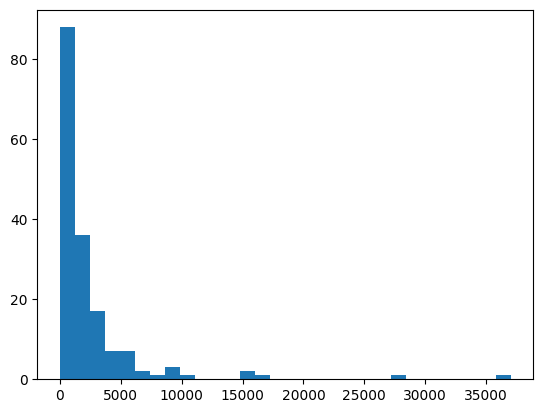

In [10]:
plt.hist(df["M_B"], bins=30)

In [4]:
mass_dict = {
    211: 139.57039,
    13: 105.6583755,
    321: 493.677,
    2212: 938.27208816,
    11: 0.51099895000
}

In [76]:
sample = "00342638_Bs_Jpsiphi_00342629_Bs_Jpsiphi"

In [78]:
sample.split("_")[1]

'Bs'

In [25]:
sig_df = reco_df[reco_df["SigLike"] == 1].copy()

In [5]:
def compute_b_kinematics(df_row):
    pid_signed = np.array([int(x) for x in df_row["final_pid"].split(",")])
    pid = np.abs(pid_signed)
    
    # Handle unknown PIDs → return -1 sentinel row
    try:
        mass = np.array([mass_dict[part] for part in pid])
    except KeyError:
        return pd.Series({"M_B": -1, "px_B": -1, "py_B": -1, "pz_B": -1,
                          "M_Jpsi": -1, "M_Phi": -1})
    
    px = np.array([float(x) for x in df_row["final_px"].split(",")]) * 1000
    py = np.array([float(x) for x in df_row["final_py"].split(",")]) * 1000
    pz = np.array([float(x) for x in df_row["final_pz"].split(",")]) * 1000
    
    E = np.sqrt(mass**2 + px**2 + py**2 + pz**2)

    # --- B meson: sum all particles ---
    E_B  = E.sum()
    px_B = px.sum()
    py_B = py.sum()
    pz_B = pz.sum()
    M_B  = np.sqrt(E_B**2 - px_B**2 - py_B**2 - pz_B**2)

    # --- J/psi: sum muons (pid == 13) ---
    mu_mask = pid == 13
    if mu_mask.sum() == 2:
        E_Jpsi  = E[mu_mask].sum()
        px_Jpsi = px[mu_mask].sum()
        py_Jpsi = py[mu_mask].sum()
        pz_Jpsi = pz[mu_mask].sum()
        M_Jpsi  = np.sqrt(E_Jpsi**2 - px_Jpsi**2 - py_Jpsi**2 - pz_Jpsi**2)
    else:
        M_Jpsi = -1

    # --- Phi: sum kaons (pid == 321) ---
    k_mask = pid == 321
    if k_mask.sum() == 2:
        E_Phi  = E[k_mask].sum()
        px_Phi = px[k_mask].sum()
        py_Phi = py[k_mask].sum()
        pz_Phi = pz[k_mask].sum()
        M_Phi  = np.sqrt(E_Phi**2 - px_Phi**2 - py_Phi**2 - pz_Phi**2)
    else:
        M_Phi = -1
    
    return pd.Series({"M_B": M_B, "px_B": px_B, "py_B": py_B, "pz_B": pz_B,
                      "M_Jpsi": M_Jpsi, "M_Phi": M_Phi})

df[["M_B", "px_B", "py_B", "pz_B", "M_Jpsi", "M_Phi"]] = df.apply(compute_b_kinematics, axis=1)

In [6]:
df

,EventNumber,SigLike,EVENTNUMBER,RUNNUMBER,final_pid,final_b_score,final_bbar_score,ft_b_score,ft_bbar_score,final_px,final_py,final_pz,M_B,px_B,py_B,pz_B,M_Jpsi,M_Phi
0,10,0.0,6.675695e+10,329778.0,"211,-211","0.4221387505531311,0.22066111862659454","0.5778456330299377,0.7793293595314026",0.321400,0.678587,"0.9222628198812117,-0.3692805106444297","-1.1933621078058252,-0.00695027420949712","7.75478791062821,1.580261282331719",1390.801169,552.982309,-1200.312382,9335.049193,-1.0,-1.0
1,22,0.0,4.800119e+10,329778.0,"211,-11,11,-211,211,1,-1","0.858656108379364,0.2931469678878784,0.8139827...","0.14132905006408691,0.706824779510498,0.185998...",0.560551,0.439430,"-0.1280771309182498,-0.023314572210374696,-0.2...","-0.5476719330854749,-0.21826200021718734,0.342...","24.703376466521945,9.801022651222809,11.250159...",-1.000000,-1.000000,-1.000000,-1.000000,-1.0,-1.0
2,22,0.0,4.800119e+10,329778.0,"-211,-211","0.1581381857395172,0.19691099226474762","0.8418422937393188,0.8030630350112915",0.177525,0.822453,"-0.5067341284944433,-0.5151875175335903","0.016448266945937817,0.016729567726167183","1.4121968188365202,1.4358182697830273",279.150296,-1021.921646,33.177835,2848.015089,-1.0,-1.0
3,23,0.0,1.544769e+10,329778.0,"-321,211","0.7076600193977356,0.7296357154846191","0.2923072576522827,0.2703327536582947",0.718648,0.281320,"-0.43414778942812404,0.5171328215016615","1.3656413486208976,-0.24220619141128807","5.123890933297346,2.23494028498547",1779.638189,82.985032,1123.435157,7358.831218,-1.0,-1.0
4,30,0.0,3.081099e+10,329778.0,"211,-211","0.3492002487182617,0.5765523314476013","0.650751531124115,0.42340806126594543",0.462876,0.537080,"0.36575053664147106,-0.6110039463375756","0.5012766291000617,-0.12283201623998075","2.7955905423412446,2.2664224259079617",1199.586358,-245.253410,378.444613,5062.012968,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,884,0.0,9.777236e+10,329778.0,"11,-211,-211,-211,-211,211,-211","0.5994392037391663,0.5359476804733276,0.558403...","0.4005219638347626,0.4640146791934967,0.441560...",0.516300,0.483664,"0.04654633159469945,0.4742008259657311,-0.2544...","0.17740085852036813,-0.7635459109515494,0.1543...","5.187018407696485,26.486353274865564,2.3033119...",4053.495074,740.678730,-955.818558,121018.943694,-1.0,-1.0
163,888,0.0,7.413457e+10,329778.0,"211,211","0.5206968784332275,0.42842504382133484","0.4792763292789459,0.5715398192405701",0.474561,0.525408,"1.7524800906906535,0.4475992240610793","-0.24152834156431524,0.130228291249054","6.572308983594837,2.3646389845197717",566.317557,2200.079315,-111.300050,8936.947968,-1.0,-1.0
164,895,0.0,2.396388e+10,329778.0,"211,211","0.5166870951652527,0.5378949046134949","0.4832823872566223,0.462074339389801",0.527291,0.472678,"0.34676851256099184,0.5880996699821139","-0.5432045392476823,-0.18427792312949975","3.5183957236808965,3.802470104329643",519.692836,934.868183,-727.482462,7320.865828,-1.0,-1.0
165,911,0.0,4.800119e+10,329778.0,"211,-211,-211,11","0.41445350646972656,0.5728855729103088,0.64348...","0.5855175852775574,0.42708519101142883,0.35648...",0.501312,0.498659,"0.16570703226958017,0.24301959280495922,-0.019...","0.641524057873383,-0.00702449137228256,-0.2219...","30.71828526312072,4.692536316717806,14.2152231...",1427.894061,408.757498,654.106107,65459.860501,-1.0,-1.0


Events in fit range [5200.0, 5500.0] MeV: 31927


/tmp/ipykernel_502/1272385590.py:51: RuntimeWarning: invalid value encountered in power
  left_tail  = Al * (Bl - t) ** (-m_l)
/tmp/ipykernel_502/1272385590.py:52: RuntimeWarning: invalid value encountered in power
  right_tail = Ar * (Br + t) ** (-m_r)
/tmp/ipykernel_502/1272385590.py:51: RuntimeWarning: invalid value encountered in power
  left_tail  = Al * (Bl - t) ** (-m_l)
/tmp/ipykernel_502/1272385590.py:52: RuntimeWarning: invalid value encountered in power
  right_tail = Ar * (Br + t) ** (-m_r)
/tmp/ipykernel_502/1272385590.py:68: RuntimeWarning: overflow encountered in exp
  return (np.exp(c * x_hi) - np.exp(c * x_lo)) / c
/tmp/ipykernel_502/1272385590.py:68: RuntimeWarning: invalid value encountered in scalar subtract
  return (np.exp(c * x_hi) - np.exp(c * x_lo)) / c
/tmp/ipykernel_502/1272385590.py:63: RuntimeWarning: overflow encountered in exp
  return np.exp(c * x)
/tmp/ipykernel_502/1272385590.py:77: RuntimeWarning: invalid value encountered in divide
  bkg_vals = exp_p


  Extended Unbinned ML — Double-sided CB + Exp
  Mean (mu)        : 5366.007  ± 0.105  MeV
  Resolution (σ)   : 14.700  ± 0.122  MeV
  Beta_L           : 1.7087 ± 0.0476
  m_L              : 1.9279 ± 0.1862
  Beta_R           : 1.8605 ± 0.0988
  m_R              : 12.4233 ± 5.6413
  Signal yield     : 31895.0 ± 189.6
  Background yield : 32.1 ± 63.6
  Exp slope (c)    : -0.00730 ± 0.00806 MeV⁻¹
  Valid fit        : True


/tmp/ipykernel_502/1272385590.py:200: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig("fit_dscb.png", dpi=150, bbox_inches='tight')
/cvmfs/sft.cern.ch/lcg/views/LCG_109_swan/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


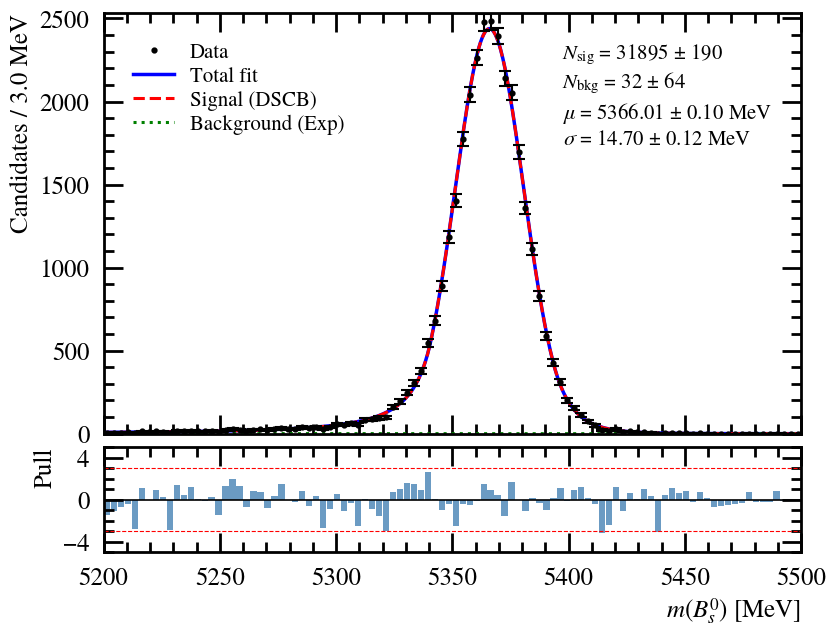

Plot saved to fit_dscb.png


In [27]:
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
hep.style.use(hep.style.LHCb2)
from iminuit import Minuit
from iminuit.cost import ExtendedUnbinnedNLL
from matplotlib.lines import Line2D

# ── USER INPUT ─────────────────────────────────────────────────────────────────
data = sig_df["M_B"].values   # already in MeV

x_min = 5200.0   # MeV
x_max = 5500.0   # MeV

# Starting values
start_mu      = 5367.0   # MeV  (B_s^0 PDG mass)
start_sigma   = 3.0      # MeV
start_beta_l  = 1.5      # left  tail exponent (> 0)
start_m_l     = 5.0      # left  tail power    (> 1)
start_beta_r  = 1.5      # right tail exponent (> 0)
start_m_r     = 5.0      # right tail power    (> 1)
start_n_sig   = 1000.0   # signal yield
start_n_bkg   = 500.0    # background yield
start_c       = -0.01    # exponential slope (MeV^-1)
# ──────────────────────────────────────────────────────────────────────────────

# Apply fit range
data = data[(data >= x_min) & (data <= x_max)]
N_data = len(data)
print(f"Events in fit range [{x_min}, {x_max}] MeV: {N_data}")

# ── PDFs ──────────────────────────────────────────────────────────────────────

def dscb_pdf(x, mu, sigma, beta_l, m_l, beta_r, m_r):
    """
    Double-sided Crystal Ball:
      - left  power-law tail for t < -|beta_l|
      - Gaussian core
      - right power-law tail for t >  |beta_r|
    """
    t  = (x - mu) / sigma
    bl = abs(beta_l)
    br = abs(beta_r)

    Al = (m_l / bl) ** m_l * np.exp(-0.5 * bl**2)
    Ar = (m_r / br) ** m_r * np.exp(-0.5 * br**2)
    Bl = m_l / bl - bl
    Br = m_r / br - br

    core       = np.exp(-0.5 * t**2)
    left_tail  = Al * (Bl - t) ** (-m_l)
    right_tail = Ar * (Br + t) ** (-m_r)

    return np.where(t < -bl, left_tail,
           np.where(t >  br, right_tail, core))

def dscb_norm(x_lo, x_hi, mu, sigma, beta_l, m_l, beta_r, m_r, n_steps=4000):
    xs = np.linspace(x_lo, x_hi, n_steps)
    ys = dscb_pdf(xs, mu, sigma, beta_l, m_l, beta_r, m_r)
    return np.trapezoid(ys, xs)

def exp_pdf(x, c):
    return np.exp(c * x)

def exp_norm(x_lo, x_hi, c):
    if abs(c) < 1e-12:
        return x_hi - x_lo
    return (np.exp(c * x_hi) - np.exp(c * x_lo)) / c

# ── Extended NLL model ────────────────────────────────────────────────────────

def scaled_pdf(x, mu, sigma, beta_l, m_l, beta_r, m_r, n_sig, n_bkg, c):
    n_total = n_sig + n_bkg
    cb_n    = dscb_norm(x_min, x_max, mu, sigma, beta_l, m_l, beta_r, m_r)
    ex_n    = exp_norm(x_min, x_max, c)
    sig_vals = dscb_pdf(x, mu, sigma, beta_l, m_l, beta_r, m_r) / cb_n
    bkg_vals = exp_pdf(x, c) / ex_n
    return n_total, n_sig * sig_vals + n_bkg * bkg_vals

cost = ExtendedUnbinnedNLL(data, scaled_pdf)

mi = Minuit(cost,
            mu=start_mu,
            sigma=start_sigma,
            beta_l=start_beta_l,
            m_l=start_m_l,
            beta_r=start_beta_r,
            m_r=start_m_r,
            n_sig=start_n_sig,
            n_bkg=start_n_bkg,
            c=start_c)

mi.limits["sigma"]  = (0.1, 100)
mi.limits["beta_l"] = (0.1, 10)
mi.limits["m_l"]    = (1.01, 50)
mi.limits["beta_r"] = (0.1, 10)
mi.limits["m_r"]    = (1.01, 50)
mi.limits["n_sig"]  = (0, N_data * 2)
mi.limits["n_bkg"]  = (0, N_data * 2)

mi.migrad()
mi.hesse()

# ── Print results ─────────────────────────────────────────────────────────────
print("\n" + "=" * 56)
print("  Extended Unbinned ML — Double-sided CB + Exp")
print("=" * 56)
print(f"  Mean (mu)        : {mi.values['mu']:.3f}  ± {mi.errors['mu']:.3f}  MeV")
print(f"  Resolution (σ)   : {mi.values['sigma']:.3f}  ± {mi.errors['sigma']:.3f}  MeV")
print(f"  Beta_L           : {mi.values['beta_l']:.4f} ± {mi.errors['beta_l']:.4f}")
print(f"  m_L              : {mi.values['m_l']:.4f} ± {mi.errors['m_l']:.4f}")
print(f"  Beta_R           : {mi.values['beta_r']:.4f} ± {mi.errors['beta_r']:.4f}")
print(f"  m_R              : {mi.values['m_r']:.4f} ± {mi.errors['m_r']:.4f}")
print(f"  Signal yield     : {mi.values['n_sig']:.1f} ± {mi.errors['n_sig']:.1f}")
print(f"  Background yield : {mi.values['n_bkg']:.1f} ± {mi.errors['n_bkg']:.1f}")
print(f"  Exp slope (c)    : {mi.values['c']:.5f} ± {mi.errors['c']:.5f} MeV⁻¹")
print(f"  Valid fit        : {mi.valid}")
print("=" * 56)

# ── Plot ──────────────────────────────────────────────────────────────────────
n_bins = 100
bin_w  = (x_max - x_min) / n_bins
counts, edges = np.histogram(data, bins=n_bins, range=(x_min, x_max))
centers = 0.5 * (edges[:-1] + edges[1:])

x_plot = np.linspace(x_min, x_max, 1000)
v      = mi.values

cb_n_fit = dscb_norm(x_min, x_max, v["mu"], v["sigma"],
                     v["beta_l"], v["m_l"], v["beta_r"], v["m_r"])
ex_n_fit = exp_norm(x_min, x_max, v["c"])

sig_curve = v["n_sig"] * dscb_pdf(x_plot, v["mu"], v["sigma"],
                                   v["beta_l"], v["m_l"],
                                   v["beta_r"], v["m_r"]) / cb_n_fit * bin_w
bkg_curve = v["n_bkg"] * exp_pdf(x_plot, v["c"]) / ex_n_fit * bin_w
tot_curve = sig_curve + bkg_curve

# Pulls
sig_c = v["n_sig"] * dscb_pdf(centers, v["mu"], v["sigma"],
                               v["beta_l"], v["m_l"],
                               v["beta_r"], v["m_r"]) / cb_n_fit * bin_w
bkg_c = v["n_bkg"] * exp_pdf(centers, v["c"]) / ex_n_fit * bin_w
fit_c = sig_c + bkg_c
errors = np.sqrt(np.maximum(counts, 1))
pulls  = (counts - fit_c) / errors

# ── Figure ────────────────────────────────────────────────────────────────────
fig, (ax_main, ax_pull) = plt.subplots(
    2, 1, figsize=(9, 7), sharex=True,
    gridspec_kw={"height_ratios": [4, 1], "hspace": 0.05}
)

LABEL_SIZE  = 18
LEGEND_SIZE = 15

ax_main.errorbar(centers, counts, yerr=errors,
                 fmt='k.', ms=6, lw=1.5, capsize=4, capthick=1.5,
                 label='Data', zorder=4)
l_tot, = ax_main.plot(x_plot, tot_curve, 'b-',  lw=2.5, label='Total fit')
l_sig, = ax_main.plot(x_plot, sig_curve, 'r--', lw=2.2, label='Signal (DSCB)')
l_bkg, = ax_main.plot(x_plot, bkg_curve, 'g:',  lw=2.2, label='Background (Exp)')

ax_main.set_ylabel(f'Candidates / {bin_w:.1f} MeV', fontsize=LABEL_SIZE)
ax_main.tick_params(axis='both', labelsize=LABEL_SIZE)

# Left legend: components
leg1 = ax_main.legend(
    handles=[ax_main.get_lines()[0], l_tot, l_sig, l_bkg],
    labels=['Data', 'Total fit', 'Signal (DSCB)', 'Background (Exp)'],
    fontsize=LEGEND_SIZE, framealpha=0.5, loc='upper left'
)
ax_main.add_artist(leg1)

# Right legend: results
dummy = [Line2D([], [], alpha=0)]
result_labels = [
    f'$N_{{\\rm sig}}$ = {v["n_sig"]:.0f} $\\pm$ {mi.errors["n_sig"]:.0f}',
    f'$N_{{\\rm bkg}}$ = {v["n_bkg"]:.0f} $\\pm$ {mi.errors["n_bkg"]:.0f}',
    f'$\\mu$ = {v["mu"]:.2f} $\\pm$ {mi.errors["mu"]:.2f} MeV',
    f'$\\sigma$ = {v["sigma"]:.2f} $\\pm$ {mi.errors["sigma"]:.2f} MeV',
]
ax_main.legend(
    handles=dummy * len(result_labels), labels=result_labels,
    fontsize=LEGEND_SIZE, framealpha=0.5,
    loc='upper right', handlelength=0, handletextpad=0
)

# Pull pad
ax_pull.bar(centers, pulls, width=bin_w * 0.9, color='steelblue', alpha=0.8)
ax_pull.axhline(0,  color='black', lw=1.2)
ax_pull.axhline( 3, color='red', lw=0.8, ls='--')
ax_pull.axhline(-3, color='red', lw=0.8, ls='--')
ax_pull.set_ylim(-5, 5)
ax_pull.set_yticks([-4, 0, 4])
ax_pull.set_ylabel('Pull', fontsize=LABEL_SIZE)
ax_pull.set_xlabel(r'$m(B_s^0)$ [MeV]', fontsize=LABEL_SIZE)
ax_pull.tick_params(axis='both', labelsize=LABEL_SIZE)

plt.savefig("fit_dscb.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to fit_dscb.png")
